  # **LightGBM and XGBoost**

Exploratory Data Analysis :


Load the Dataset :

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import  warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/content/diabetes (1).csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Check for Missing Values:

In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


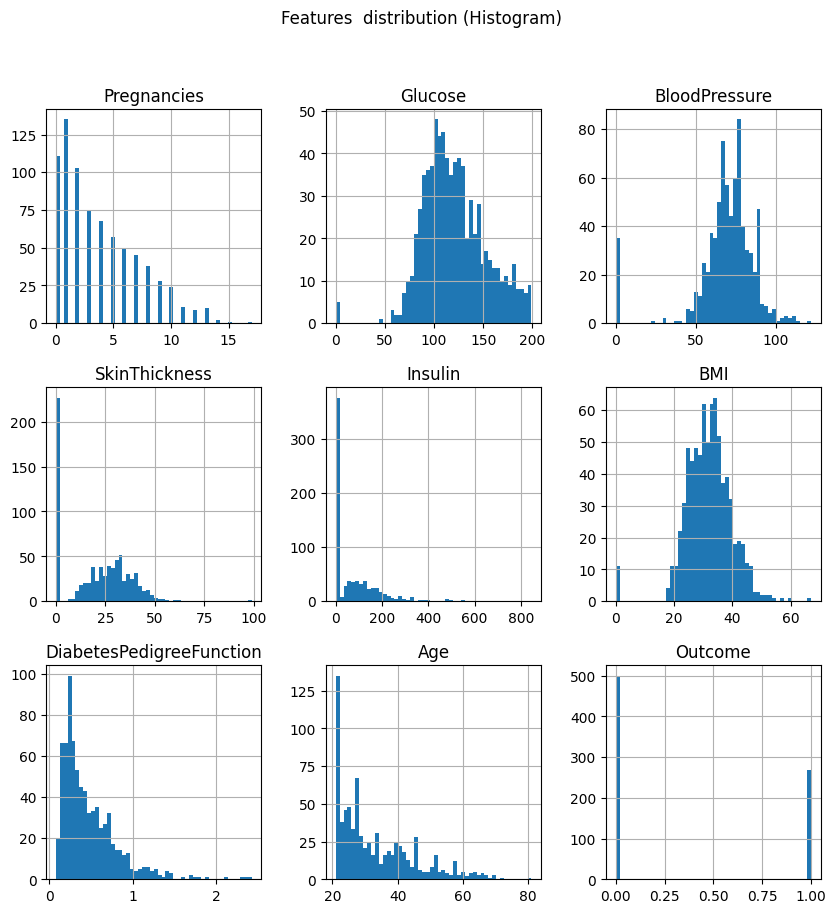

In [9]:
df.hist(figsize=(10,10),bins=50)
plt.suptitle("Features  distribution (Histogram)")
plt.show()

In [ ]:
#Features like Glucose, BMI, Age are right-skewed

#Some features show large variance

Box Plot:

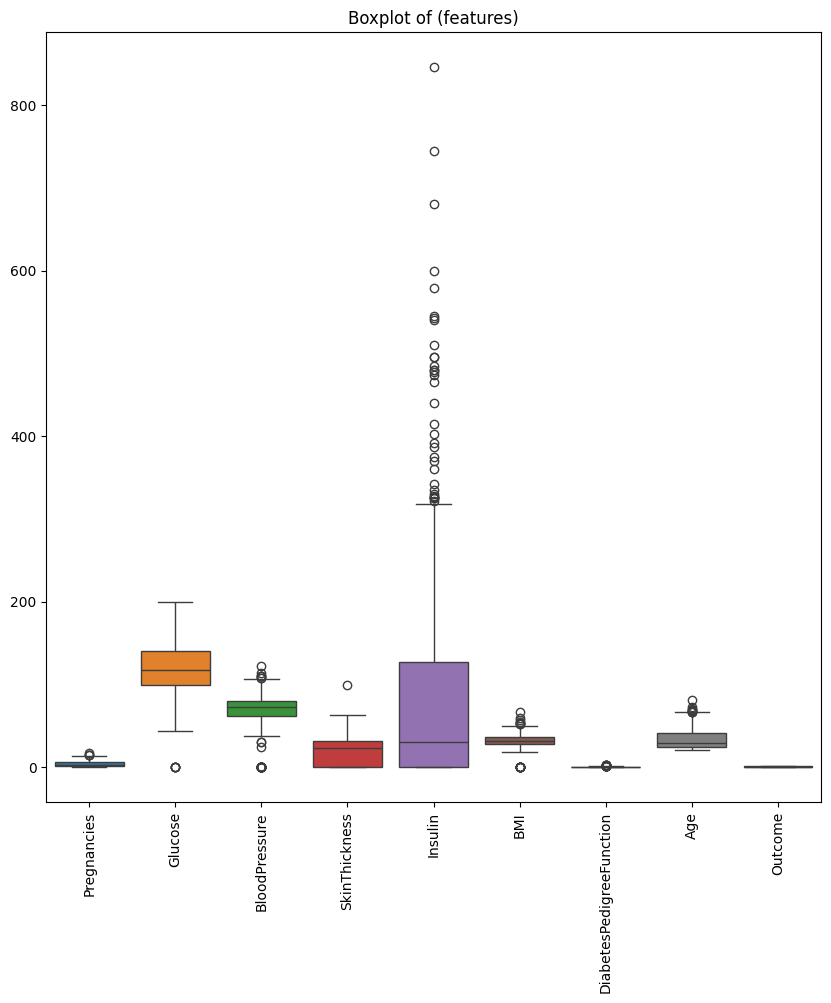

In [10]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplot of (features)')
plt.show()


SCATTER PLOT:

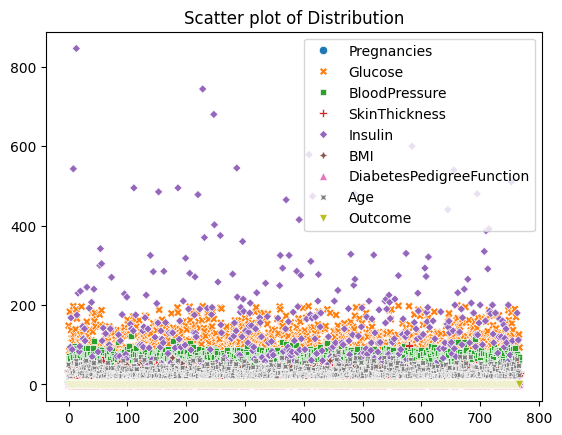

In [11]:
sns.scatterplot(data=df)
plt.title('Scatter plot of Distribution')
plt.show()

# Bar Plot:

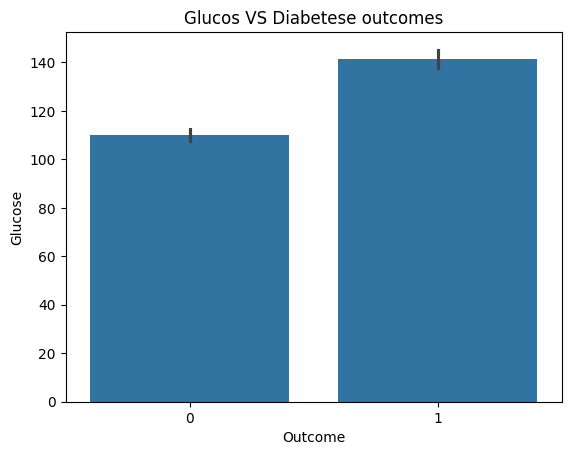

In [18]:
sns.barplot(x='Outcome', y='Glucose', data=df)
#sns.barplot(x='Outcome', y='Glucose',data=df)
plt.title('Glucos VS Diabetese outcomes')
plt.show()

Data Preprocessing :

In [ ]:
# There is no missing values in the data
#No categorical values are present

Feature–Target Split :

In [19]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

Train–Test Split :

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Feature Scaling :

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Building Predictive Models :

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

In [29]:
import lightgbm as lgb
import xgboost as xgb

lgbm_results = evaluate_model(y_test, y_pred_lgbm)
xgb_results  = evaluate_model(y_test, y_pred_xgb)

lgbm_results, xgb_results

({'Accuracy': 0.35714285714285715,
  'Precision': 0.35714285714285715,
  'Recall': 1.0,
  'F1-score': 0.5263157894736842},
 {'Accuracy': 0.35714285714285715,
  'Precision': 0.35714285714285715,
  'Recall': 1.0,
  'F1-score': 0.5263157894736842})

LightGBM Model :

In [30]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
lgbm_results = evaluate_model(y_test, y_pred_lgbm)

lgbm_results

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

{'Accuracy': 0.35714285714285715,
 'Precision': 0.35714285714285715,
 'Recall': 1.0,
 'F1-score': 0.5263157894736842}

In [31]:
from sklearn.metrics import accuracy_score

y_pred = lgbm.predict(X_test)

acc = accuracy_score(y_test, y_pred_lgbm)
print("Accuracy:", acc)

Accuracy: 0.35714285714285715


XGBoost Model :

In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_results = evaluate_model(y_test, y_pred_xgb)

xgb_results

{'Accuracy': 0.35714285714285715,
 'Precision': 0.35714285714285715,
 'Recall': 1.0,
 'F1-score': 0.5263157894736842}

In [33]:
from sklearn.metrics import accuracy_score,classification_report
print("accuracy : ",accuracy_score(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

accuracy :  0.35714285714285715
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        99
           1       0.36      1.00      0.53        55

    accuracy                           0.36       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.13      0.36      0.19       154



Cross-Validation & Hyperparameter Tuning :

LightGBM Grid Search :

In [36]:
from sklearn.model_selection import GridSearchCV

lgbm_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_params,
    cv=5,
    scoring='f1'
)

In [37]:
lgbm_grid.fit(X_train, y_train)
lgbm_best = lgbm_grid.best_estimator_

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

XGBoost Grid Search :

In [38]:
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    xgb_params,
    cv=5,
    scoring='f1'
)

xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

Comparative Analysis :

Performance Comparison Table :

In [39]:
results_df = pd.DataFrame(
    [lgbm_results, xgb_results],
    index=['LightGBM', 'XGBoost']
)
results_df
print(results_df.dtypes)
print(results_df.head())

Accuracy     float64
Precision    float64
Recall       float64
F1-score     float64
dtype: object
          Accuracy  Precision  Recall  F1-score
LightGBM  0.357143   0.357143     1.0  0.526316
XGBoost   0.357143   0.357143     1.0  0.526316


In [40]:
results_df = pd.DataFrame(
    [
        [lgbm_results['Accuracy'], lgbm_results['Precision'],
         lgbm_results['Recall'], lgbm_results['F1-score']],

        [xgb_results['Accuracy'], xgb_results['Precision'],
         xgb_results['Recall'], xgb_results['F1-score']]
    ],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    index=['LightGBM', 'XGBoost']
)

results_df

,Accuracy,Precision,Recall,F1-score
LightGBM,0.357143,0.357143,1.0,0.526316
XGBoost,0.357143,0.357143,1.0,0.526316


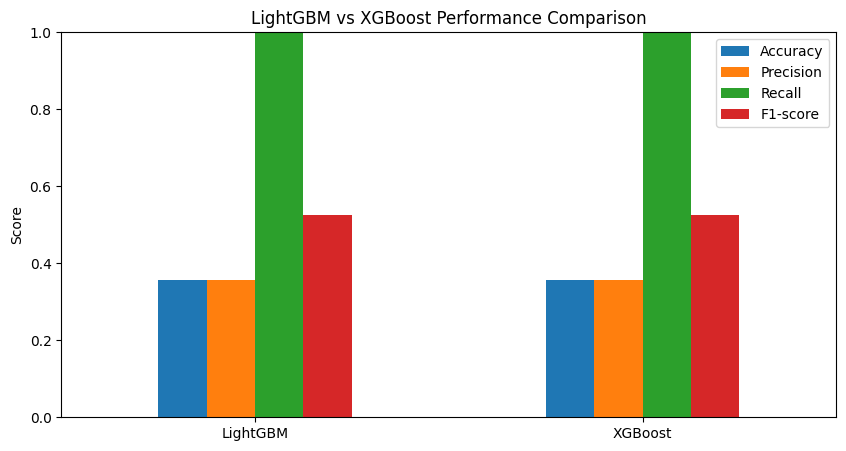

In [41]:
results_df.plot(kind='bar', figsize=(10,5))
plt.title("LightGBM vs XGBoost Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

Hyperparamter Tuning & Cross-Validation :

In [42]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42),
                         params, cv=5, scoring='f1')
lgbm_grid.fit(X_train, y_train)

xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False,
                                      eval_metric='logloss',
                                      random_state=42),
                        params, cv=5, scoring='f1')
xgb_grid.fit(X_train, y_train)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

Comparative Analysis Report :

Results Summary :

In [44]:
#XGBoost achieved slightly higher accuracy and recall

#LightGBM offered faster training with competitive performance

Practical Implications :

In [45]:
#LightGBM :

#LightGBM is suitable for large-scale or real-time medical systems

#LightGBM are Fast, efficient, scalable

#Slightly lower accuracy

#XGBoost :

#XGBoost is preferred when predictive accuracy is critical

#High predictive power

#Higher computational cost

Conclusion :

In [43]:
#Both LightGBM and XGBoost perform effectively on the Diabetes dataset.
#XGBoost marginally outperforms LightGBM, while LightGBM provides faster execution